In [2]:

%matplotlib inline

import numpy as np
import pandas as pd
import json
import collections

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.transforms import RandomNodeSplit as masking
from torch_geometric.utils.convert import to_networkx

import networkx as nx


In [9]:

with open("C:/Users/satvi/OneDrive/Desktop/proj1-SNA-using-GNN/dataset/musae_git_features.json") as json_data:
    data_raw = json.load(json_data)
edges=pd.read_csv("C:/Users/satvi/OneDrive/Desktop/proj1-SNA-using-GNN/dataset/musae_git_edges.csv")
target_df=pd.read_csv("C:/Users/satvi/OneDrive/Desktop/proj1-SNA-using-GNN/dataset/musae_git_target.csv")

print("raw data:")
for i, (key, value) in enumerate(data_raw.items()):
    if i >= 5:  
        break
    print(f"{key}: {value}")

print()

print("target nodes:")
print(target_df.head(5).to_markdown())

print()

print("edge nodes:")
print(edges.head(5).to_markdown())

raw data:
0: [1574, 3773, 3571, 2672, 2478, 2534, 3129, 3077, 1171, 2045, 1539, 902, 1532, 2472, 1122, 2480, 3098, 2115, 1578]
1: [1193, 376, 73, 290, 3129, 1852, 3077, 1171, 1022, 2045, 536, 2040, 1533, 1532, 2472, 673, 798]
2: [1574, 3773, 925, 1728, 2815, 2963, 3077, 364, 1171, 536, 1867, 2472, 1122, 2532, 664, 28, 3311, 1768, 869]
3: [3964, 3773, 4003, 928, 1852, 3077, 364, 1022, 3763, 2045, 3859, 3771, 234, 664, 703]
4: [1929, 3773, 1793, 3511, 1290, 3129, 3077, 364, 1171, 1022, 2045, 536, 1119, 91, 1532, 3771, 1122, 703, 1001]

target nodes:
|    |   id | name         |   ml_target |
|---:|-----:|:-------------|------------:|
|  0 |    0 | Eiryyy       |           0 |
|  1 |    1 | shawflying   |           0 |
|  2 |    2 | JpMCarrilho  |           1 |
|  3 |    3 | SuhwanCha    |           0 |
|  4 |    4 | sunilangadi2 |           1 |

edge nodes:
|    |   id_1 |   id_2 |
|---:|-------:|-------:|
|  0 |      0 |  23977 |
|  1 |      1 |  34526 |
|  2 |      1 |   2370 |
|  3 | 

In [11]:
feats=[]
feat_counts=[]
for i in range(len(data_raw)):
    feat_counts+=[len(data_raw[str(i)])]
    feats+=data_raw[str(i)]

print("feats: ", feats)

feats:  [1574, 3773, 3571, 2672, 2478, 2534, 3129, 3077, 1171, 2045, 1539, 902, 1532, 2472, 1122, 2480, 3098, 2115, 1578, 1193, 376, 73, 290, 3129, 1852, 3077, 1171, 1022, 2045, 536, 2040, 1533, 1532, 2472, 673, 798, 1574, 3773, 925, 1728, 2815, 2963, 3077, 364, 1171, 536, 1867, 2472, 1122, 2532, 664, 28, 3311, 1768, 869, 3964, 3773, 4003, 928, 1852, 3077, 364, 1022, 3763, 2045, 3859, 3771, 234, 664, 703, 1929, 3773, 1793, 3511, 1290, 3129, 3077, 364, 1171, 1022, 2045, 536, 1119, 91, 1532, 3771, 1122, 703, 1001, 1574, 3773, 1793, 2934, 1088, 2465, 1618, 1233, 2282, 2947, 2211, 1087, 3129, 1852, 3077, 1171, 3763, 2045, 536, 137, 3849, 1532, 2472, 2371, 2266, 703, 3964, 509, 3214, 581, 364, 1171, 1022, 3763, 2045, 1366, 1532, 2472, 3794, 3711, 1193, 1249, 1663, 819, 1171, 1022, 2045, 1026, 2311, 1532, 2472, 3794, 664, 703, 1193, 1051, 3571, 3129, 1171, 3763, 2045, 536, 128, 1532, 3771, 2371, 2749, 3827, 2602, 2657, 1360, 1793, 1290, 3129, 1852, 364, 1022, 2045, 536, 1927, 3375, 1532, 377

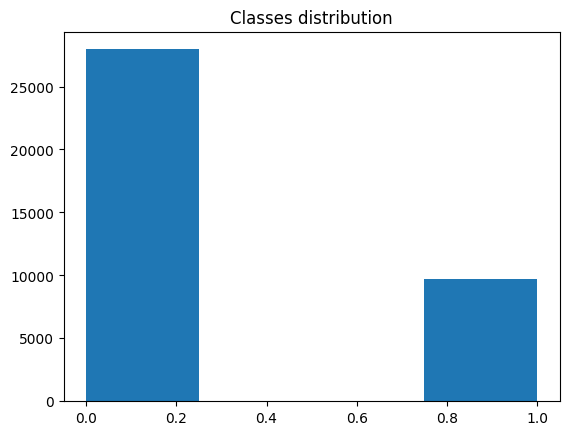

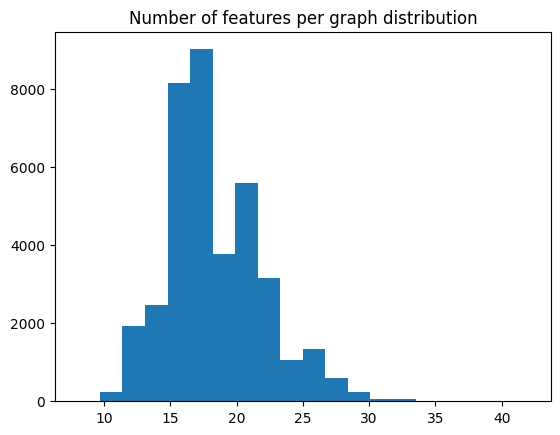

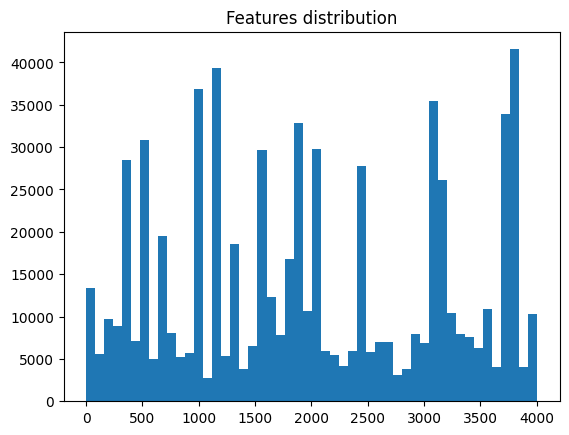

In [4]:
plt.hist(target_df.ml_target,bins=4,);
plt.title("Classes distribution")
plt.show()

plt.hist(feat_counts,bins=20)
plt.title("Number of features per graph distribution")
plt.show()

plt.hist(feats,bins=50)
plt.title("Features distribution")
plt.show()

In [5]:
counter=collections.Counter(feats)
print(list(counter.keys())[:10])
print(list(counter.values())[:10])
print(list(counter.keys())[-10:])
print(list(counter.values())[-10:])
#data_encoded

[1574, 3773, 3571, 2672, 2478, 2534, 3129, 3077, 1171, 2045]
[5045, 12726, 2486, 298, 165, 510, 22075, 28188, 24958, 21449]
[936, 172, 875, 3548, 2745, 793, 1941, 464, 2616, 3124]
[1, 2, 1, 2, 1, 1, 1, 1, 1, 1]


In [6]:
def encode_data(light=False,n=60):
    if light==True:
        nodes_included=n
    elif light==False:
        nodes_included=len(data_raw)
    
    data_encoded={}
    for i in range(nodes_included):# 
        one_hot_feat=np.array([0]*(max(feats)+1))
        this_feat=data_raw[str(i)]
        one_hot_feat[this_feat]=1
        data_encoded[str(i)]=list(one_hot_feat)
    
    if light==True:
        sparse_feat_matrix=np.zeros((1,max(feats)+1))
        for j in range(nodes_included):
            temp=np.array(data_encoded[str(j)]).reshape(1,-1)
            sparse_feat_matrix=np.concatenate((sparse_feat_matrix,temp),axis=0)
        sparse_feat_matrix=sparse_feat_matrix[1:,:]
        return(data_encoded,sparse_feat_matrix)
    elif light==False:
        return(data_encoded, None)

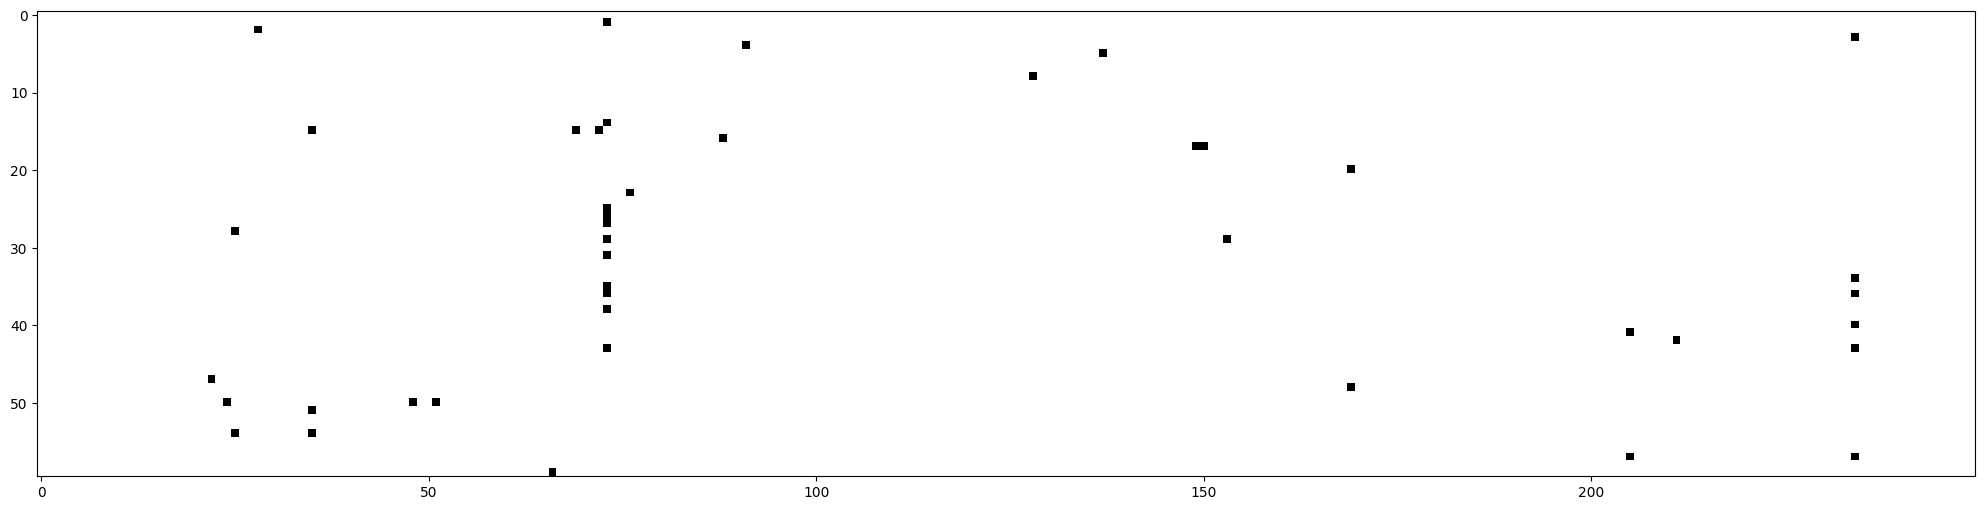

In [7]:
data_encoded_vis,sparse_feat_matrix_vis=encode_data(light=True,n=60)
plt.figure(figsize=(25,25));
plt.imshow(sparse_feat_matrix_vis[:,:250],cmap='Greys');
#plt.grid()

In [8]:
def construct_graph(data_encoded,light=False):
    node_features_list=list(data_encoded.values())
    node_features=torch.tensor(node_features_list)
    node_labels=torch.tensor(target_df['ml_target'].values)
    edges_list=edges.values.tolist()
    edge_index01=torch.tensor(edges_list, dtype = torch.long).T
    edge_index02=torch.zeros(edge_index01.shape, dtype = torch.long)#.T
    edge_index02[0,:]=edge_index01[1,:]
    edge_index02[1,:]=edge_index01[0,:]
    edge_index0=torch.cat((edge_index01,edge_index02),axis=1)
    g = Data(x=node_features, y=node_labels, edge_index=edge_index0)
    g_light = Data(x=node_features[:,0:2],
                     y=node_labels   ,
                     edge_index=edge_index0[:,:55])
    if light:
        return(g_light)
    else:
        return(g)

In [9]:
#g_top_draw = Data(x=node_features, y=node_labels, edge_index=edge_index0)

def draw_graph(data0):
    #node_labels=data0.y
    if data0.num_nodes>100:
        print("This is a big graph, can not plot...")
        return
        
    else:
        data_nx = to_networkx(data0)
        node_colors=data0.y[list(data_nx.nodes)]
        pos= nx.spring_layout(data_nx,scale =1)
        plt.figure(figsize=(12,8))
        nx.draw(data_nx, pos,  cmap=plt.get_cmap('Set1'),
                node_color =node_colors,node_size=600,connectionstyle="angle3",
                width =1, with_labels = False, edge_color = 'k', arrowstyle = "-")

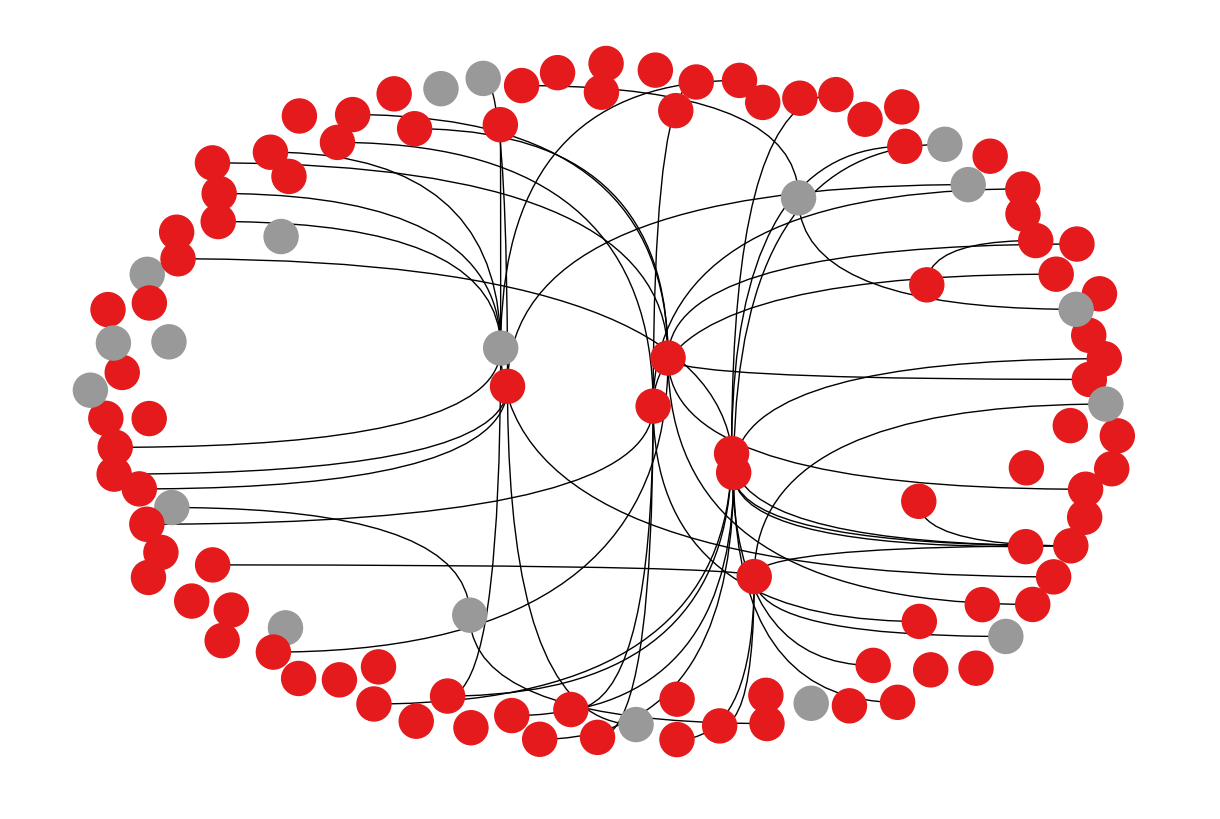

In [10]:
g_sample=construct_graph(data_encoded=data_encoded_vis,light=True)
draw_graph(g_sample)

# Model

In [11]:
data_encoded,_=encode_data(light=False)

In [12]:
g=construct_graph(data_encoded=data_encoded,light=False)

In [13]:
from torch_geometric.transforms import RandomNodeSplit as masking


In [14]:
msk=masking(split="train_rest", num_splits = 1, num_val = 0.3, num_test= 0.6)
g=msk(g)
print(g)
print()
print("training samples",torch.sum(g.train_mask).item())
print("validation samples",torch.sum(g.val_mask ).item())
print("test samples",torch.sum(g.test_mask ).item())

Data(x=[37700, 4005], edge_index=[2, 578006], y=[37700], train_mask=[37700], val_mask=[37700], test_mask=[37700])

training samples 3770
validation samples 11310
test samples 22620


In [15]:
class SocialGNN(torch.nn.Module):
    def __init__(self,num_of_feat,f):
        super(SocialGNN, self).__init__()


        self.conv1 = GCNConv(num_of_feat, f)

        self.conv2 = GCNConv(f, 2)


    def forward(self, data):
        x = data.x.float()
        edge_index =  data.edge_index
          
        x = self.conv1(x=x, edge_index=edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        return x

In [16]:
def masked_loss(predictions,labels,mask):
    mask=mask.float()
    mask=mask/torch.mean(mask)
    loss=criterion(predictions,labels)
    loss=loss*mask
    loss=torch.mean(loss)
    return (loss)  

In [17]:
def masked_accuracy(predictions,labels,mask):
    mask=mask.float()
    mask/=torch.mean(mask)
    accuracy=(torch.argmax(predictions,axis=1)==labels).long()
    accuracy=mask*accuracy
    accuracy=torch.mean(accuracy)
    return (accuracy)

In [31]:
def train_social(net,data,epochs=10,lr=0.01):
    optimizer = torch.optim.Adam(net.parameters(), lr=lr) # 00001
    best_accuracy=0.0
    
    train_losses=[]
    train_accuracies=[]

    val_losses=[]
    val_accuracies=[]

    test_losses=[]
    test_accuracies=[]
    
    for ep in range(epochs+1):
        optimizer.zero_grad()
        out=net(data)
        loss=masked_loss(predictions=out,
                         labels=data.y,
                         mask=data.train_mask)
        loss.backward()
        optimizer.step()
        train_losses+=[loss]
        train_accuracy=masked_accuracy(predictions=out,
                                       labels=data.y, 
                                       mask=data.train_mask)
        train_accuracies+=[train_accuracy]
        
        val_loss=masked_loss(predictions=out,
                             labels=data.y, 
                             mask=data.val_mask)
        val_losses+=[val_loss]
        
        val_accuracy=masked_accuracy(predictions=out,
                                     labels=data.y, 
                                     mask=data.val_mask)
        val_accuracies+=[val_accuracy]

        test_accuracy=masked_accuracy(predictions=out,
                                      labels=data.y, 
                                      mask=data.test_mask)
        test_accuracies+=[test_accuracy]
        if np.round(val_accuracy,4)> np.round(best_accuracy ,4):
            print("Epoch {}/{}, Train_Loss: {:.4f}, Train_Accuracy: {:.4f}, Val_Accuracy: {:.4f}, Test_Accuracy: {:.4f}"
                      .format(ep+1,epochs, loss.item(), train_accuracy, val_accuracy,  test_accuracy))
            best_accuracy=val_accuracy

    
    plt.plot(train_accuracies) 
    plt.plot(val_accuracies)
    plt.plot(test_accuracies) 
    # plt.show()

Epoch 1/50, Train_Loss: 0.6719, Train_Accuracy: 0.7499, Val_Accuracy: 0.7460, Test_Accuracy: 0.7416
Epoch 3/50, Train_Loss: 0.5979, Train_Accuracy: 0.7631, Val_Accuracy: 0.7589, Test_Accuracy: 0.7558
Epoch 5/50, Train_Loss: 0.4322, Train_Accuracy: 0.8634, Val_Accuracy: 0.8622, Test_Accuracy: 0.8553
Epoch 12/50, Train_Loss: 0.3404, Train_Accuracy: 0.8679, Val_Accuracy: 0.8671, Test_Accuracy: 0.8626
Epoch 13/50, Train_Loss: 0.3475, Train_Accuracy: 0.8719, Val_Accuracy: 0.8705, Test_Accuracy: 0.8654
Epoch 17/50, Train_Loss: 0.3361, Train_Accuracy: 0.8740, Val_Accuracy: 0.8714, Test_Accuracy: 0.8664
Epoch 18/50, Train_Loss: 0.3279, Train_Accuracy: 0.8700, Val_Accuracy: 0.8723, Test_Accuracy: 0.8666
Epoch 24/50, Train_Loss: 0.3261, Train_Accuracy: 0.8732, Val_Accuracy: 0.8737, Test_Accuracy: 0.8674
Epoch 26/50, Train_Loss: 0.3203, Train_Accuracy: 0.8743, Val_Accuracy: 0.8744, Test_Accuracy: 0.8700
Epoch 29/50, Train_Loss: 0.3230, Train_Accuracy: 0.8761, Val_Accuracy: 0.8748, Test_Accuracy: 

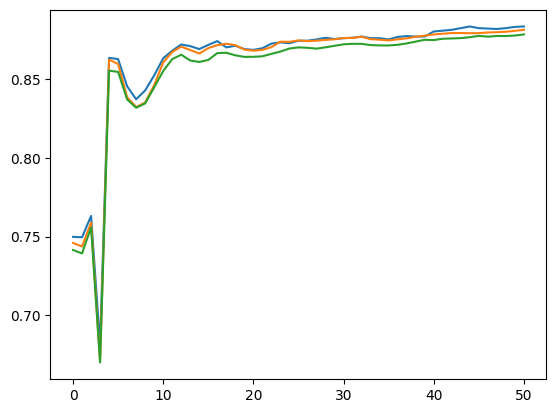

In [32]:
num_of_feat=g.num_node_features
net=SocialGNN(num_of_feat=num_of_feat,f=16)
criterion=nn.CrossEntropyLoss()
train_social(net,g,epochs=50,lr=0.1)